<a href="https://colab.research.google.com/github/RagaSandhiya05/Superstore_Sales_Dashboard/blob/main/Superstore_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
#Import Libraries & Load Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme()

In [28]:
# Load Excel file
file_path = "/content/Superstores_Sales.xls"
df = pd.read_excel(file_path)

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Create new columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()
df['Delivery_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

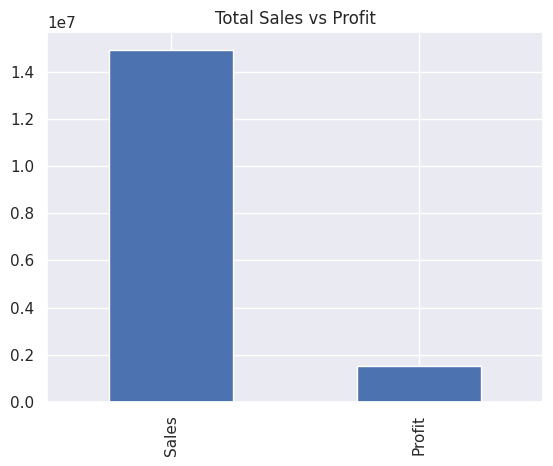

In [29]:
df[['Sales','Profit']].sum().plot(kind='bar', title='Total Sales vs Profit')
plt.show()

In [30]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Order Priority', 'Order Quantity',
       'Sales', 'Discount', 'Ship Mode', 'Profit', 'Unit Price',
       'Shipping Cost', 'Customer Name', 'Province', 'Region',
       'Customer Segment', 'Product Category', 'Product Sub-Category',
       'Product Name', 'Product Container', 'Product Base Margin', 'Ship Date',
       'Year', 'Month', 'Month_Name', 'Delivery_Days'],
      dtype='object')


In [31]:
# Clean Column Names
df.columns = df.columns.str.strip()

In [32]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Order Priority', 'Order Quantity',
       'Sales', 'Discount', 'Ship Mode', 'Profit', 'Unit Price',
       'Shipping Cost', 'Customer Name', 'Province', 'Region',
       'Customer Segment', 'Product Category', 'Product Sub-Category',
       'Product Name', 'Product Container', 'Product Base Margin', 'Ship Date',
       'Year', 'Month', 'Month_Name', 'Delivery_Days'],
      dtype='object')


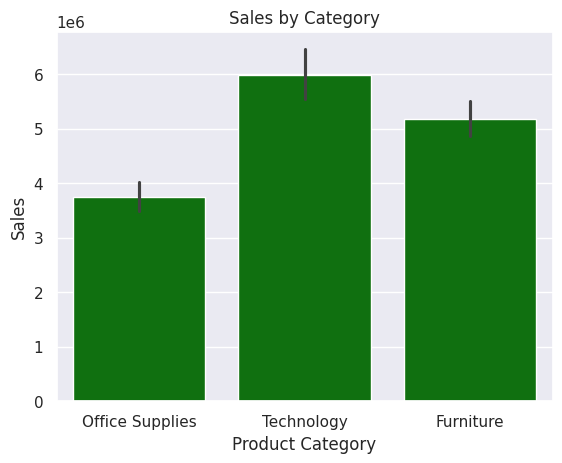

In [33]:
sns.barplot(data=df, x='Product Category', y='Sales', estimator=sum , color = 'Green')
plt.title("Sales by Category")
plt.show()

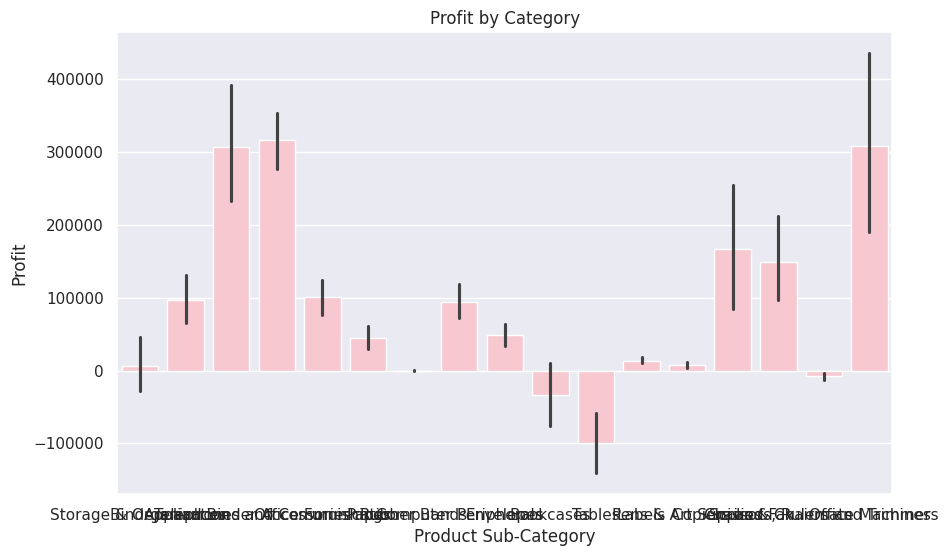

In [34]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Product Sub-Category', y='Profit', estimator=sum , color = 'Pink')
plt.title("Profit by Category")
plt.show()

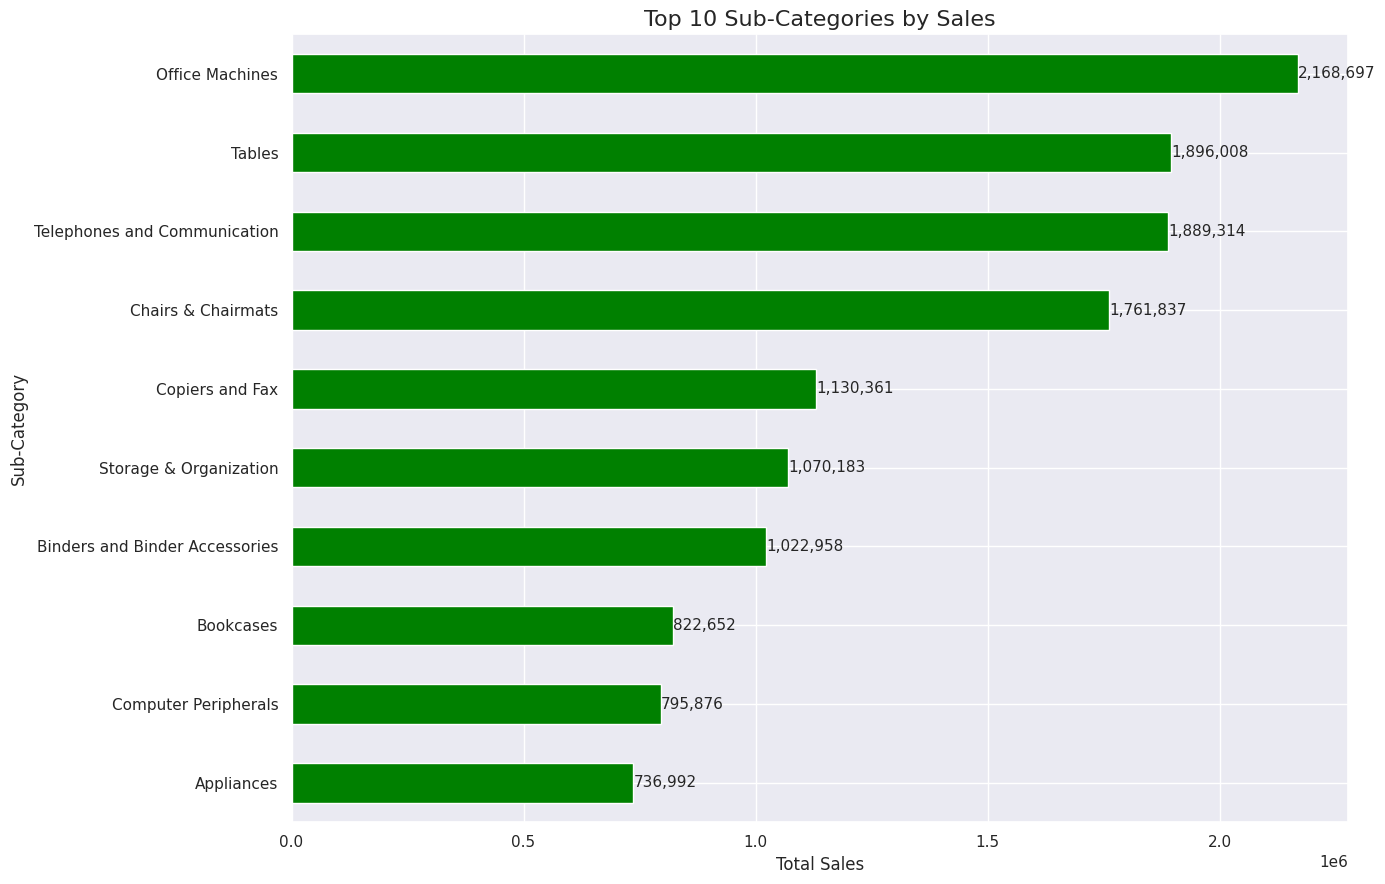

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 9))
top_sub = (df.groupby('Product Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10))
ax = top_sub.plot(kind='barh' , color = 'Green')

# Add numbers on bars
for i, value in enumerate(top_sub.values):ax.text(value, i , f'{value:,.0f}', va='center', ha='left', fontsize=11)
ax.invert_yaxis()
plt.title("Top 10 Sub-Categories by Sales", fontsize=16)
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

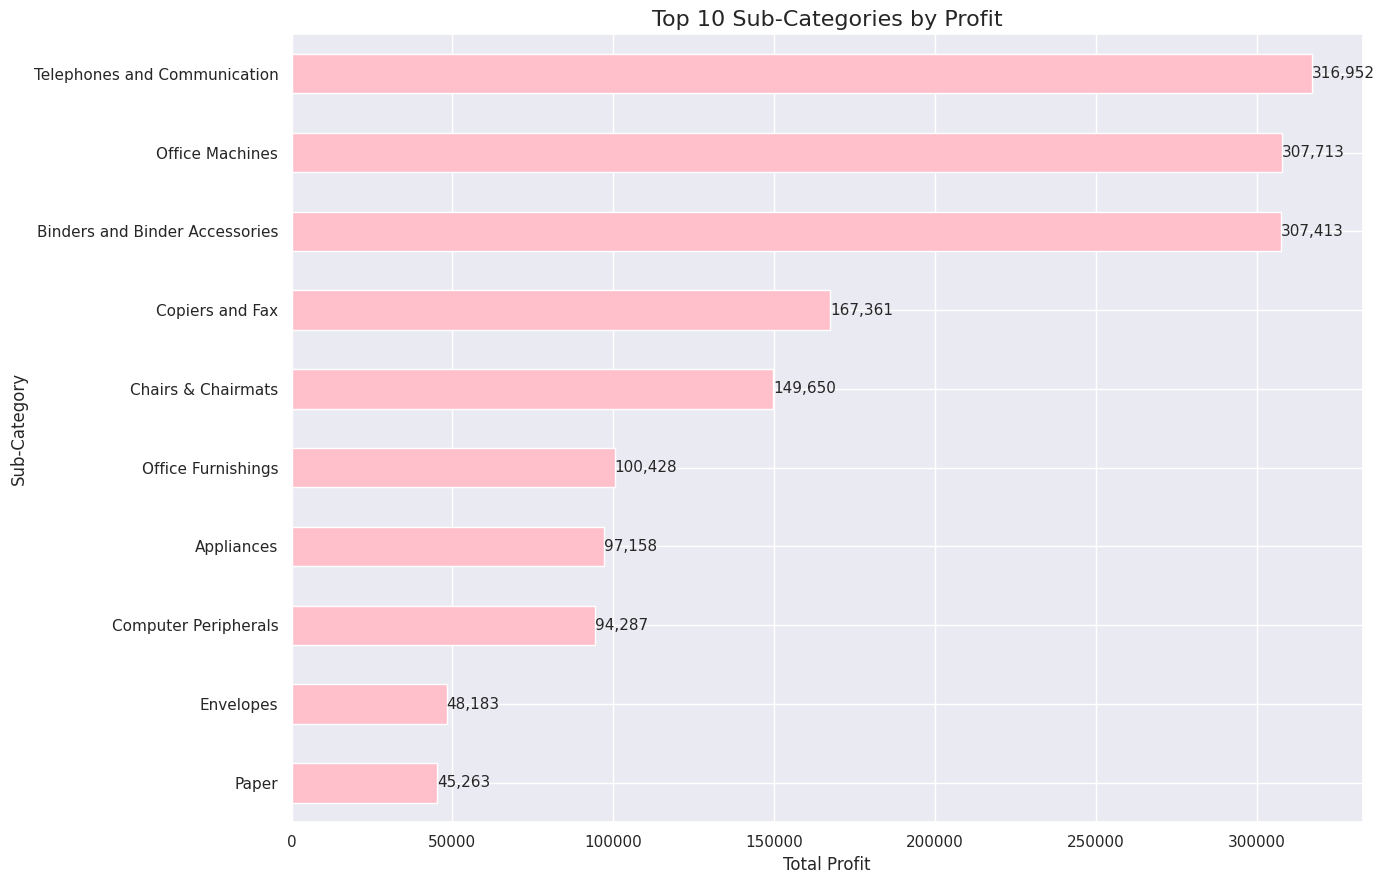

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 9))
top_sub = (df.groupby('Product Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10))
ax = top_sub.plot(kind='barh' , color = 'Pink')

# Add numbers on bars
for i, value in enumerate(top_sub.values):ax.text(value, i , f'{value:,.0f}', va='center', ha='left', fontsize=11)
ax.invert_yaxis()
plt.title("Top 10 Sub-Categories by Profit", fontsize=16)
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

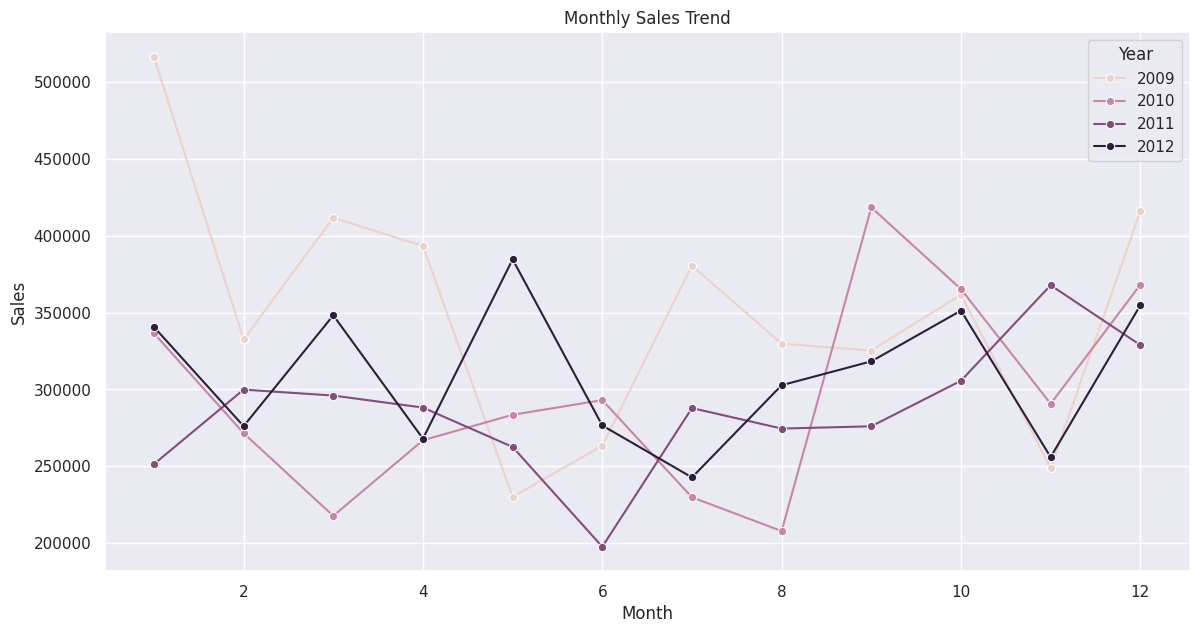

In [37]:
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
plt.figure(figsize=(14, 7))
ax = sns.lineplot(data=monthly_sales, x='Month', y='Sales', hue='Year', marker='o')
plt.title("Monthly Sales Trend")
plt.show()

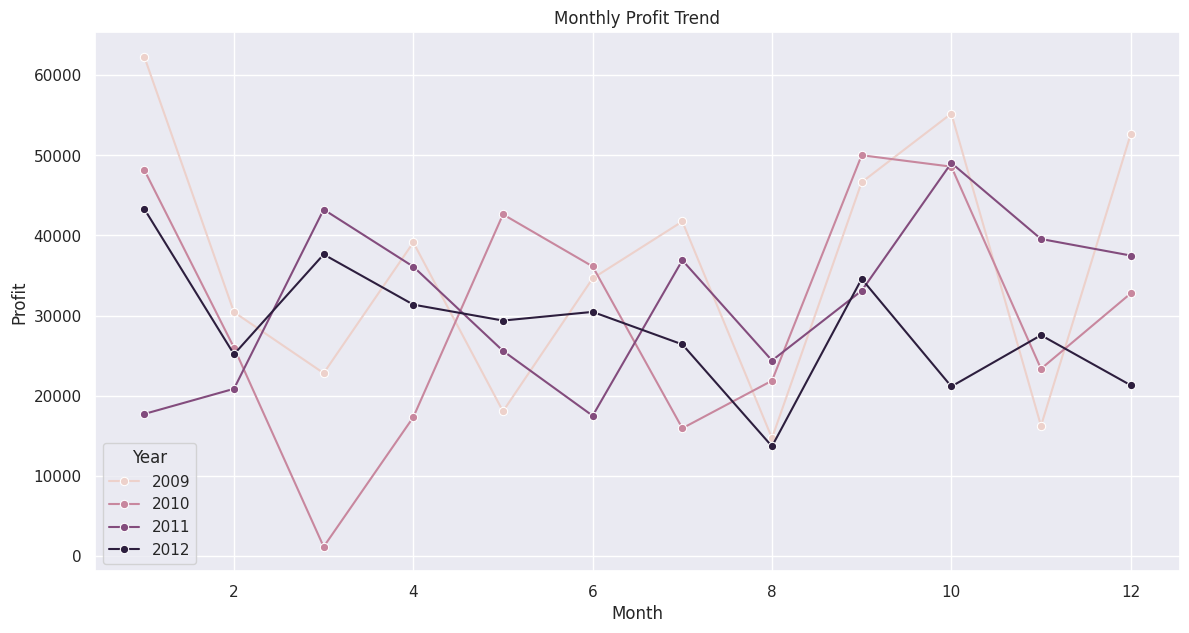

In [38]:
monthly_sales = df.groupby(['Year','Month'])['Profit'].sum().reset_index()
plt.figure(figsize=(14, 7))
ax = sns.lineplot(data=monthly_sales, x='Month', y='Profit', hue='Year', marker='o')
plt.title("Monthly Profit Trend")
plt.show()

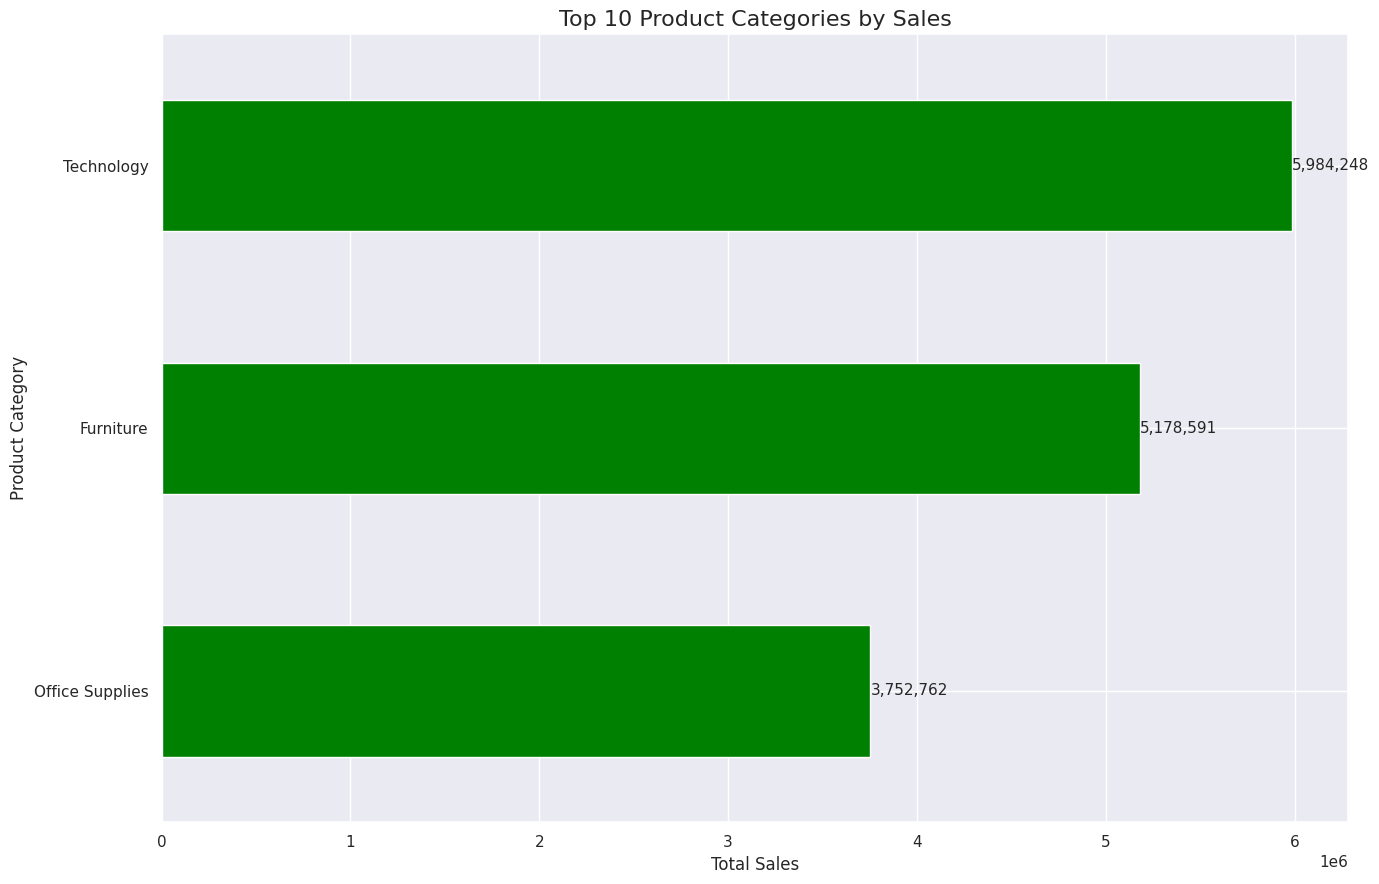

In [39]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 9))
top_sub = (df.groupby('Product Category')['Sales'].sum().sort_values(ascending=False).head(10))
ax = top_sub.plot(kind='barh' , color = 'Green')

# Add numbers on bars
for i, value in enumerate(top_sub.values):ax.text(value, i , f'{value:,.0f}', va='center', ha='left', fontsize=11)
ax.invert_yaxis()
plt.title("Top 10 Product Categories by Sales", fontsize=16)
plt.xlabel("Total Sales")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

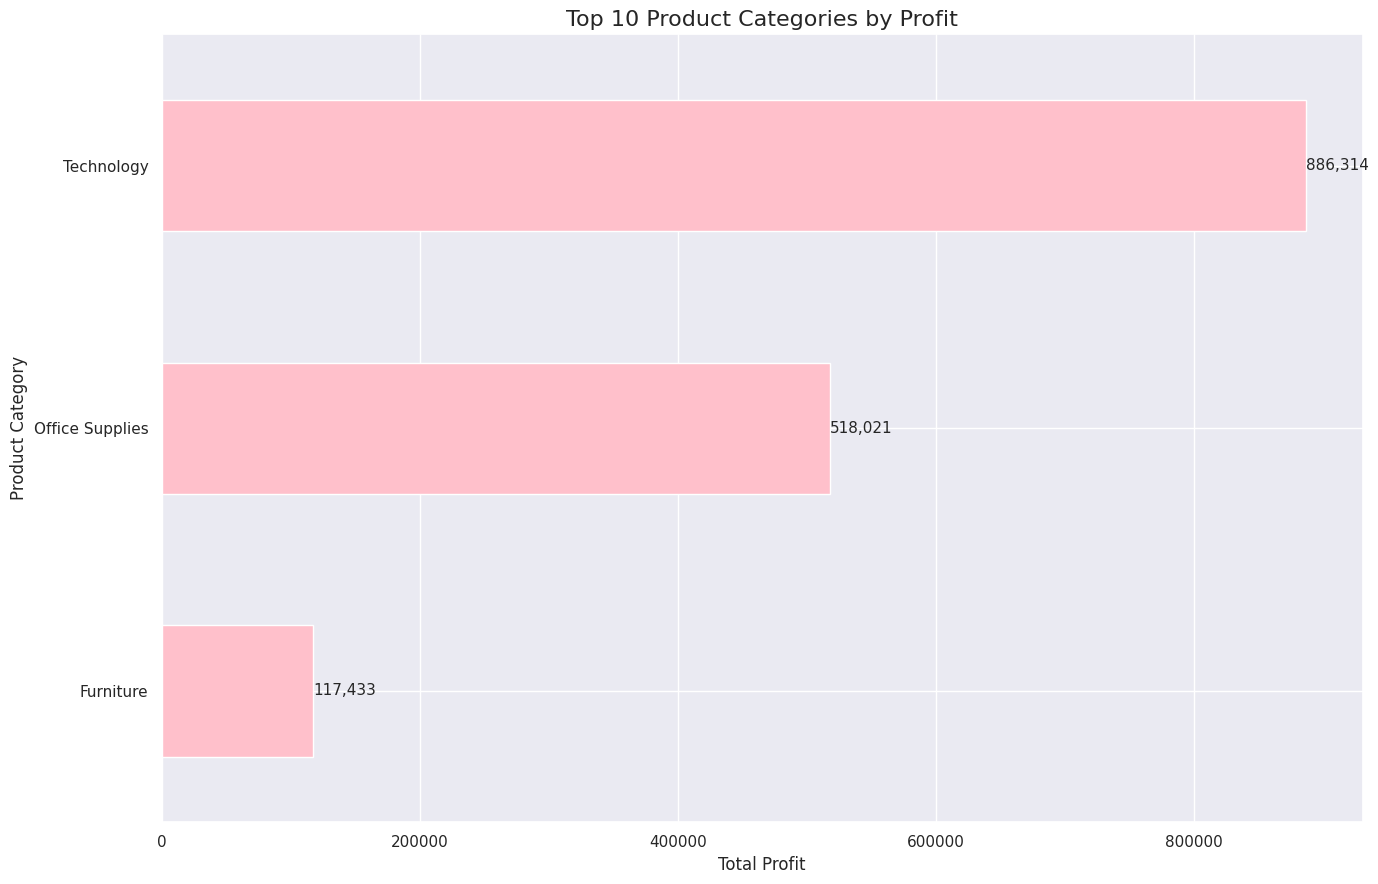

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 9))
top_sub = (df.groupby('Product Category')['Profit'].sum().sort_values(ascending=False).head(10))
ax = top_sub.plot(kind='barh' , color = 'Pink')

# Add numbers on bars
for i, value in enumerate(top_sub.values):ax.text(value, i , f'{value:,.0f}', va='center', ha='left', fontsize=11)
ax.invert_yaxis()
plt.title("Top 10 Product Categories by Profit", fontsize=16)
plt.xlabel("Total Profit")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

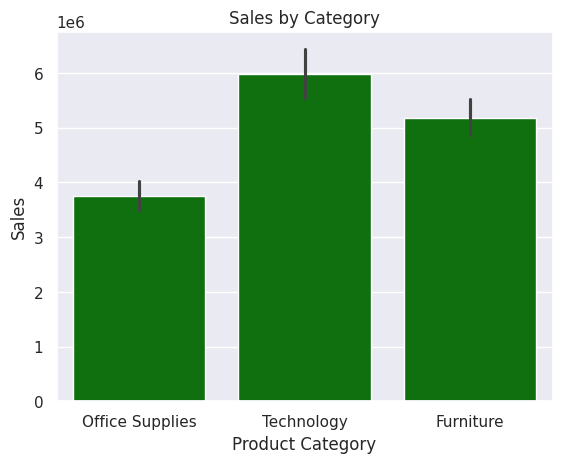

<Figure size 1200x700 with 0 Axes>

In [41]:
#Sales by Category (Bar Chart)
def add_bar_labels(ax , orientation = 'v'):
 plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df, x='Product Category', y='Sales', estimator=sum , color = 'Green')
plt.title("Sales by Category")
add_bar_labels(ax, orientation='v')
plt.show()

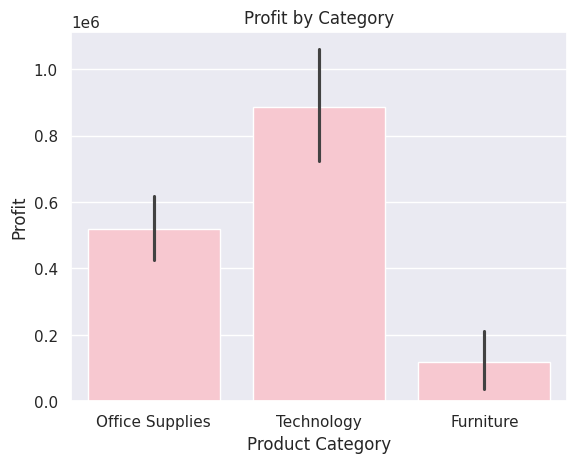

<Figure size 1200x700 with 0 Axes>

In [42]:
#Sales by Category (Bar Chart)
def add_bar_labels(ax , orientation = 'v'):
 plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df, x='Product Category', y='Profit', estimator=sum , color = 'Pink')
plt.title("Profit by Category")
add_bar_labels(ax, orientation='v')
plt.show()

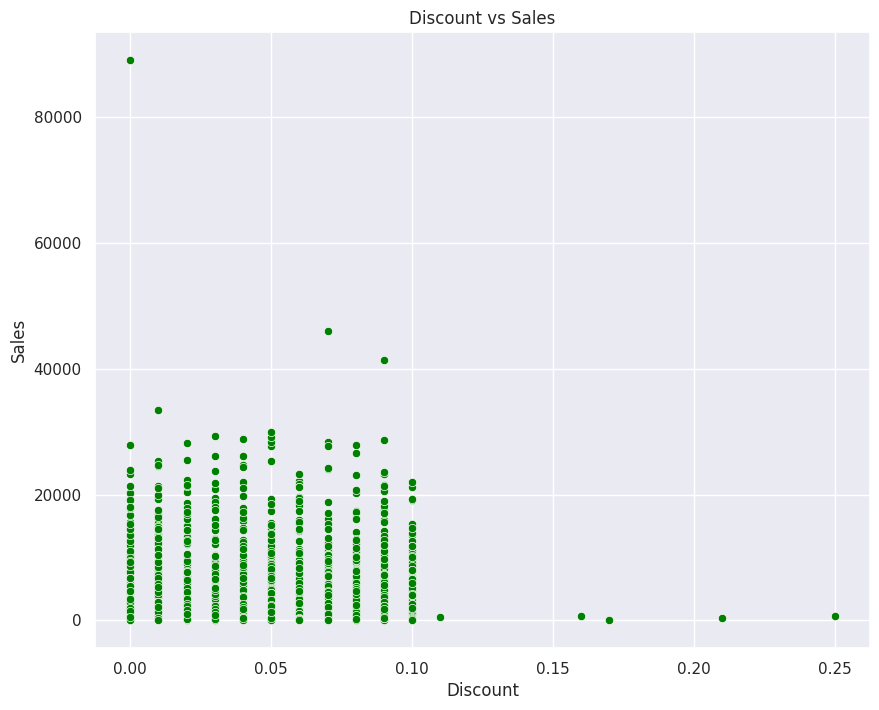

In [43]:
plt.figure(figsize = (10,8))
sns.scatterplot(data = df , x = 'Discount' , y = 'Sales' , color = 'Green')
plt.title('Discount vs Sales')
plt.show()

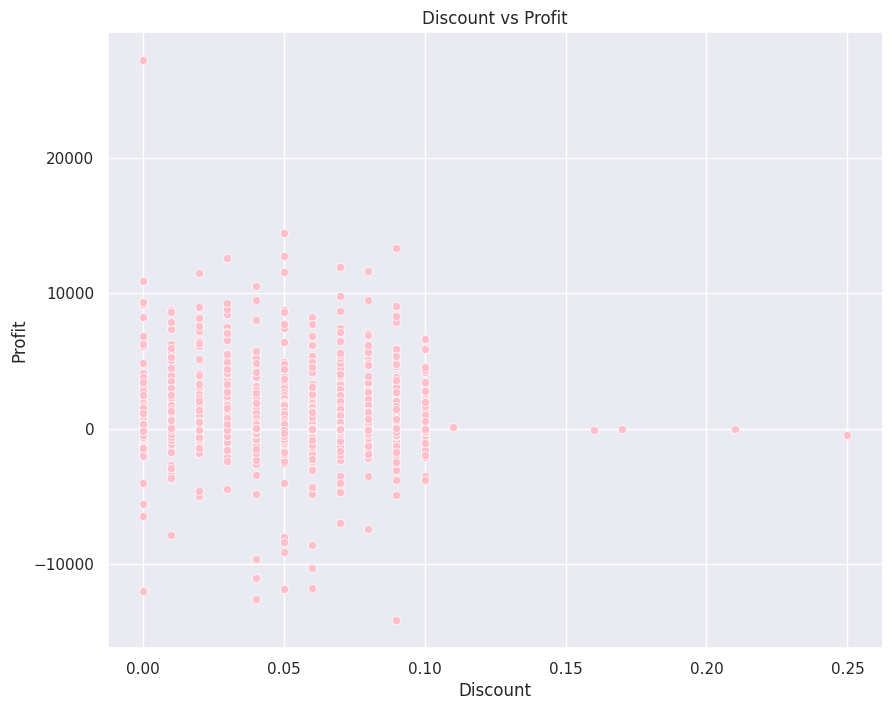

In [44]:
plt.figure(figsize = (10,8))
sns.scatterplot(data = df , x = 'Discount' , y = 'Profit' , color = 'Pink')
plt.title('Discount vs Profit')
plt.show()

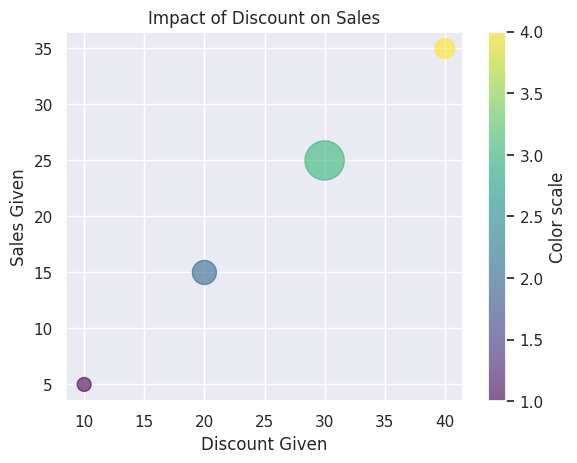

In [45]:
x = [10, 20, 30, 40]
y = [5, 15, 25, 35]
sizes = [100, 300, 800, 200]
colors = [1 , 2 , 3 , 4]
plt.scatter(x, y, s=sizes, c=colors, alpha=0.6, cmap='viridis')
plt.xlabel("Discount Given")
plt.ylabel("Sales Given")
plt.title("Impact of Discount on Sales")
plt.colorbar(label="Color scale")
plt.show()

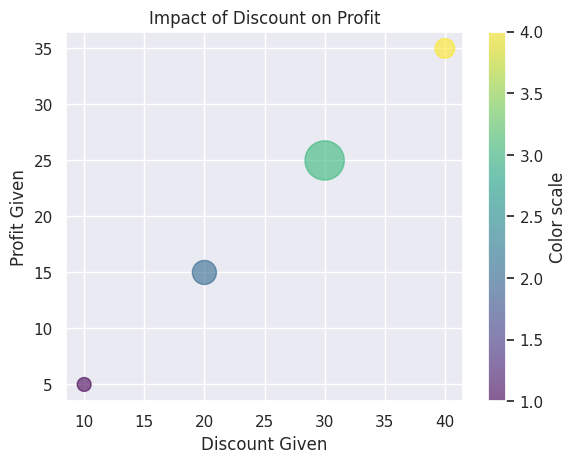

In [46]:
x = [10, 20, 30, 40]
y = [5, 15, 25, 35]
sizes = [100, 300, 800, 200]
colors = [1 , 2 , 3 , 4]
plt.scatter(x, y, s=sizes, c=colors, alpha=0.6, cmap='viridis')
plt.xlabel("Discount Given")
plt.ylabel("Profit Given")
plt.title("Impact of Discount on Profit")
plt.colorbar(label="Color scale")
plt.show()

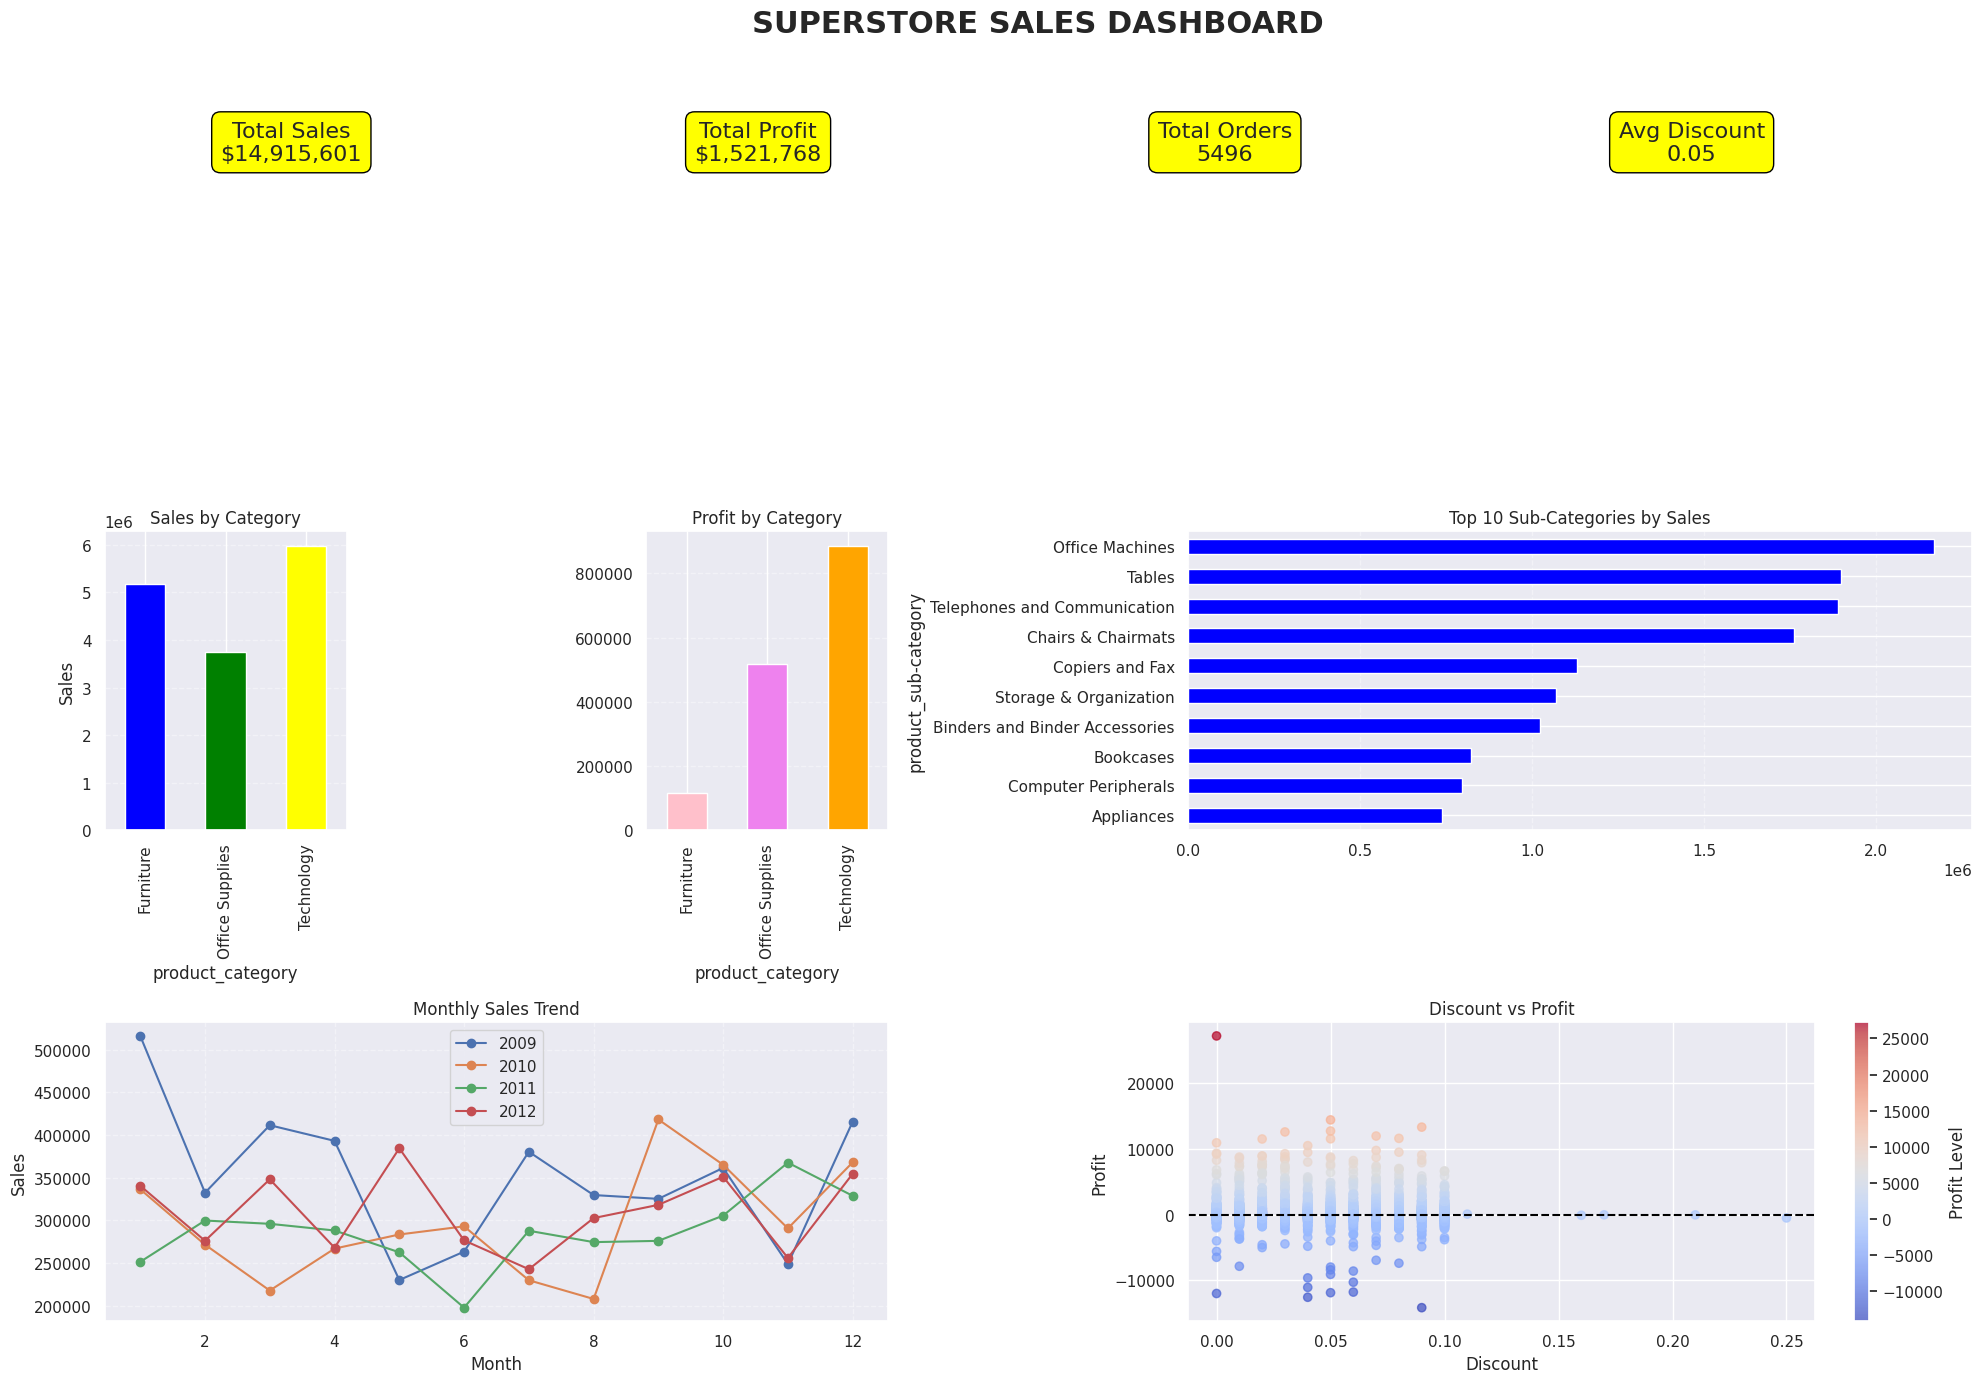

In [47]:
# Importing the Libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = "/content/Superstores_Sales.xls"
df = pd.read_excel(file_path, sheet_name="Orders")

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Date features
df['order_date'] = pd.to_datetime(df['order_date'])
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

# KPI calculations
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()
avg_discount = df['discount'].mean()

# Create dashboard canvas
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 4)

# KPI Section
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')

kpi_box = dict(boxstyle="round,pad=0.4", fc="Yellow", ec="black")

ax_kpi.text(0.1, 0.6, f"Total Sales\n${total_sales:,.0f}",
            fontsize=16, ha='center', bbox=kpi_box)
ax_kpi.text(0.35, 0.6, f"Total Profit\n${total_profit:,.0f}",
            fontsize=16, ha='center', bbox=kpi_box)
ax_kpi.text(0.6, 0.6, f"Total Orders\n{total_orders}",
            fontsize=16, ha='center', bbox=kpi_box)
ax_kpi.text(0.85, 0.6, f"Avg Discount\n{avg_discount:.2f}",
            fontsize=16, ha='center', bbox=kpi_box)

ax_kpi.set_title("SUPERSTORE SALES DASHBOARD",
                 fontsize=22, fontweight='bold')

# Sales by Category
ax1 = fig.add_subplot(gs[1, 0])
df.groupby('product_category')['sales'].sum().plot(
    kind='bar', ax=ax1, color=['Blue', 'Green', 'Yellow']
)
ax1.set_title("Sales by Category")
ax1.set_ylabel("Sales")
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Profit by Category
ax2 = fig.add_subplot(gs[1, 1])
df.groupby('product_category')['profit'].sum().plot(
    kind='bar', ax=ax2, color=['Pink', 'Violet', 'Orange']
)
ax2.set_title("Profit by Category")
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# Top 10 Sub-Categories
ax3 = fig.add_subplot(gs[1, 2:])
df.groupby('product_sub-category')['sales'].sum() \
  .sort_values(ascending=False).head(10) \
  .plot(kind='barh', ax=ax3, color='Blue')
ax3.set_title("Top 10 Sub-Categories by Sales")
ax3.invert_yaxis()
ax3.grid(axis='x', linestyle='--', alpha=0.4)

# Monthly Sales Trend
ax4 = fig.add_subplot(gs[2, :2])
monthly_sales = df.groupby(['year', 'month'])['sales'].sum().reset_index()

for y in monthly_sales['year'].unique():
    temp = monthly_sales[monthly_sales['year'] == y]
    ax4.plot(temp['month'], temp['sales'], marker='o', label=str(y))

ax4.set_title("Monthly Sales Trend")
ax4.set_xlabel("Month")
ax4.set_ylabel("Sales")
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.4)

# Discount vs Profit
ax5 = fig.add_subplot(gs[2, 2:])
scatter = ax5.scatter(
    df['discount'],
    df['profit'],
    c=df['profit'],
    cmap='coolwarm',
    alpha=0.7
)
ax5.axhline(0, linestyle='--', color='black')
ax5.set_title("Discount vs Profit")
ax5.set_xlabel("Discount")
ax5.set_ylabel("Profit")
fig.colorbar(scatter, ax=ax5, label="Profit Level")

# Final Layout
plt.tight_layout()
plt.show()

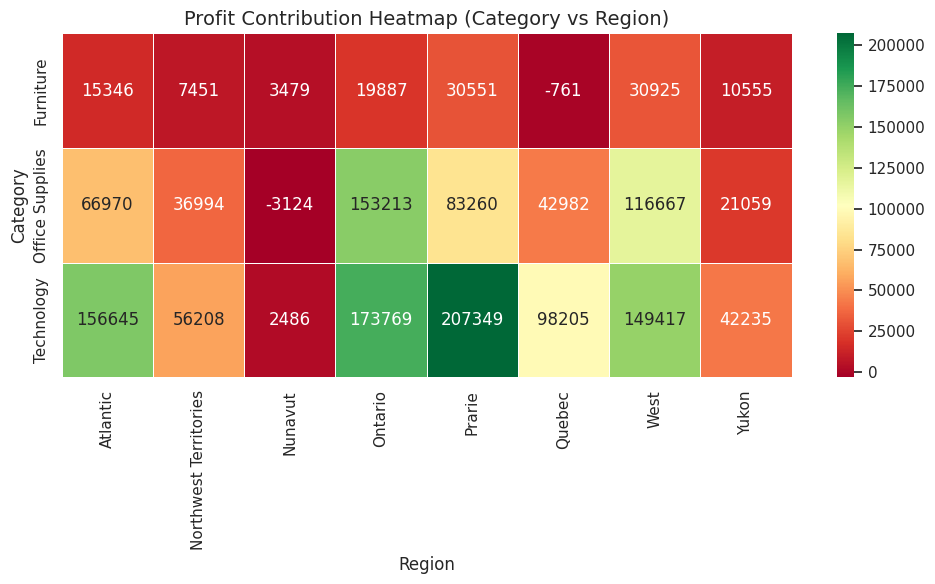

In [48]:
# Importing the Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot table for profit
profit_pivot = pd.pivot_table(
    df,
    values='profit',
    index='product_category',
    columns='region',
    aggfunc='sum'
)

# Plot heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    profit_pivot,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title("Profit Contribution Heatmap (Category vs Region)", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Category")

plt.tight_layout()
plt.show()